# MonsoonBench: Probabilistic Model Comparison Walkthrough

This notebook demonstrates how to generate the following visualizations:
1. Brier Skill Score and AUC heat maps
2. Brier Skill Score, Ranked Probability Skill Score, and Area Under Curve Score dual axis comparisons between different models
3. Reliability diagrams

## 1. Setup and Imports

In [ ]:
from pathlib import Path
import os
import monsoonbench
from monsoonbench.visualization import (
    create_heatmap,
)

# Find the project root dynamically
current_file_path = Path(os.getcwd())
repo_root = next(
    (p for p in current_file_path.parents if (p / "pyproject.toml").exists()),
    current_file_path.parent.parent.parent,
)

# Define absolute paths + create output directory
data_dir = repo_root / "data"
output_dir = repo_root / "examples/demo_notebooks/outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"MonsoonBench version: {monsoonbench.__version__}")
print(f"Available functions: {monsoonbench.__all__}")

MonsoonBench version: 0.1.0
Available functions: ['__version__', 'main', 'load', 'get_registered', 'register_loader', 'DeterministicOnsetMetrics', 'ProbabilisticOnsetMetrics', 'ClimatologyOnsetMetrics', 'load_config', 'plot_spatial_metrics']


## 2. BSS and AUC Heat Maps

In [2]:
# Set base config
base_config = {
    # Required arguments
    # Directory containing IMD rainfall data
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    # Path to IMD onset threshold file
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    # Optional arguments with defaults
    # File pattern for model data
    "file_pattern": "{}.nc",
    # Maximum forecast day (15 or 30)
    "max_forecast_day": 30,
    # Directory to save output files
    "save_dir": output_dir,
    # Use MOK date filter (June 2nd) for onset detection
    "mok": True,
}

### IFS-S2S Model

#### Period: 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ifs
Years: [2019, 2020, 2021, 2022, 2023]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021, 2022, 2023]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 11 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)

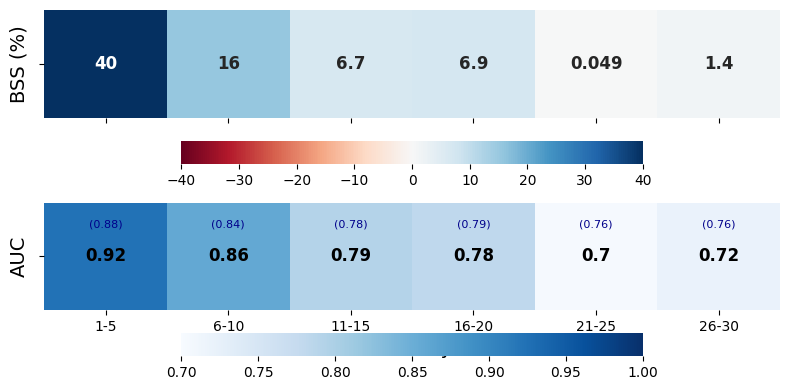

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_ifs_30day.png'


In [ ]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    # Model name for output files
    "model_name": "ifs",
    # Number of ensemble members to use
    "mem_num": 11,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
create_heatmap(config)

#### Period: 2004-2021

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ifs
Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Pro

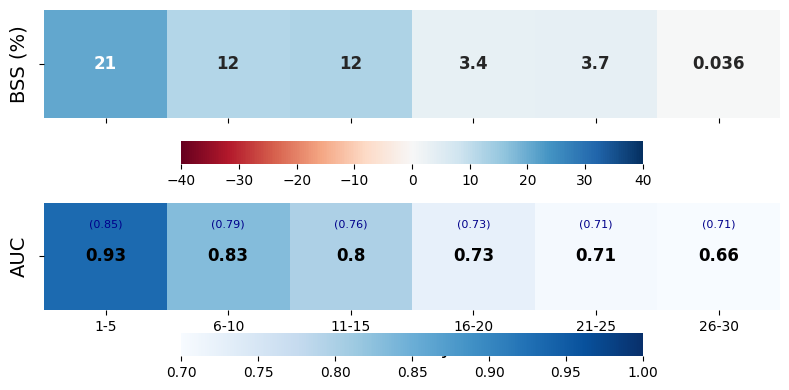

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_ifs_30day.png'


In [7]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    # Model name for output files
    "model_name": "ifs",
    # Number of ensemble members to use
    "mem_num": 11,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
create_heatmap(config)

### Gencast Model

#### Period: 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: gencast
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021, 2022, 2023, 2024]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), 

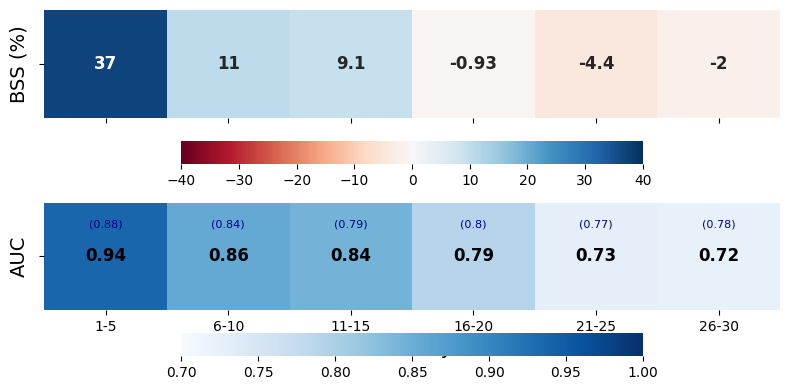

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_gencast_30day.png'


In [4]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/gencast52/tp_lsm_4p0",
    # Model name for output files
    "model_name": "gencast",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
create_heatmap(config)

### Fuxi S2S Model

#### Period: 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: fuxi-s2s
Years: [2019, 2020, 2021]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0

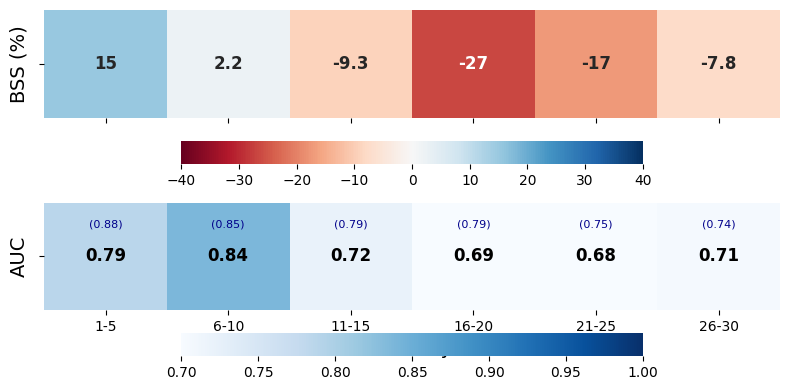

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_fuxi-s2s_30day.png'


In [5]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
    # Model name for output files
    "model_name": "fuxi-s2s",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021],
    # Year to use for date filtering
    "date_filter_year": 2022,
}
config = base_config | model_config
create_heatmap(config)

#### Period: 2004-2021

In [8]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
    # Model name for output files
    "model_name": "fuxi-s2s",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2022,
}
config = base_config | model_config
create_heatmap(config)

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: fuxi-s2s
Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members..

KeyboardInterrupt: 

### NGCM Model (Climatology)

#### Period: 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ngcm
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021, 2022, 2023, 2024]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.

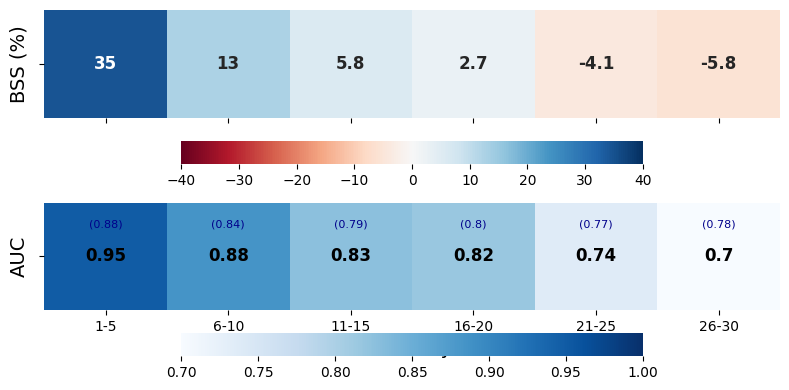

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_ngcm_30day.png'


In [6]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/climatology/tp_4p0",
    # Model name for output files
    "model_name": "ngcm",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
create_heatmap(config)

#### Period: 2004-2021

In [ ]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/climatology/tp_4p0",
    # Model name for output files
    "model_name": "ngcm",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
create_heatmap(config)